# 포트폴리오 2호 — CWRU 베어링 진동 데이터 분석
**구본준 | 2026-06-23**

진동 신호 → 특징 추출 → RandomForest 결함 분류 → 결함 크기 교차 검증

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
from scipy.stats import kurtosis, skew
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)
import pathlib, urllib.request, platform, warnings
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['font.size'] = 11
print('로드 완료 |', platform.system(), '| 폰트:', plt.rcParams['font.family'])

로드 완료 | Windows | 폰트: ['Malgun Gothic']


## 1. 베어링 구조 & 결함 종류

```
[외륜(OR)] ← 케이싱에 고정, 회전 안 함
    [볼]   ← 굴러다님
[내륜(IR)] ← 축과 함께 회전

하중대: 중력이 작용하는 6시 방향 — 볼이 눌리는 영역
```

| 결함 | 충격 원리 | Kurtosis 예측 |
|------|----------|---------------|
| OR (6시) | 외륜 고정 → 볼이 항상 같은 자리 강타 | 최고 |
| IR | 내륜 회전 → 결함이 하중대를 들어왔다 나갔다 | 중간 |
| Ball | 볼 자전으로 충격 불규칙 | Normal과 유사 |

In [2]:
DATA_DIR = pathlib.Path('data') / 'cwru'
DATA_DIR.mkdir(parents=True, exist_ok=True)

FILES_007 = {
    'Normal': ('97.mat',  'https://engineering.case.edu/sites/default/files/97.mat'),
    'IR':     ('105.mat', 'https://engineering.case.edu/sites/default/files/105.mat'),
    'OR':     ('130.mat', 'https://engineering.case.edu/sites/default/files/130.mat'),
    'Ball':   ('118.mat', 'https://engineering.case.edu/sites/default/files/118.mat'),
}
FILES_014 = {
    'Normal': ('97.mat',  'https://engineering.case.edu/sites/default/files/97.mat'),
    'IR':     ('169.mat', 'https://engineering.case.edu/sites/default/files/169.mat'),
    'OR':     ('197.mat', 'https://engineering.case.edu/sites/default/files/197.mat'),
    'Ball':   ('185.mat', 'https://engineering.case.edu/sites/default/files/185.mat'),
}

COLORS   = {'Normal':'steelblue', 'IR':'tomato', 'OR':'darkorange', 'Ball':'mediumseagreen'}
LABEL_KR = {'Normal':'정상', 'IR':'내륜 결함', 'OR':'외륜 결함', 'Ball':'볼 결함'}
CLASS_ORDER = ['Normal', 'Ball', 'IR', 'OR']

all_files = {}
for d in [FILES_007, FILES_014]:
    for label, (fname, url) in d.items():
        all_files[fname] = url

print('=== 데이터 다운로드 ===')
for fname, url in all_files.items():
    fp = DATA_DIR / fname
    if fp.exists() and fp.stat().st_size > 5000:
        print(f'  {fname:10s} {fp.stat().st_size//1024} KB 이미 있음')
    else:
        print(f'  {fname:10s} 다운로드 중...')
        try:
            urllib.request.urlretrieve(url, fp)
            if fp.stat().st_size < 5000: raise RuntimeError('파일 너무 작음')
            print(f'             완료 {fp.stat().st_size//1024} KB')
        except Exception as e:
            print(f'             실패: {e}')
            print(f'             수동: {url}')

=== 데이터 다운로드 ===
  97.mat     3811 KB 이미 있음
  105.mat    2842 KB 이미 있음
  130.mat    2859 KB 이미 있음
  118.mat    2873 KB 이미 있음
  169.mat    2856 KB 이미 있음
  197.mat    2856 KB 이미 있음
  185.mat    2856 KB 이미 있음


In [3]:
def load_cwru(fp):
    fp = pathlib.Path(fp)
    if not fp.exists():
        raise FileNotFoundError(f'없음: {fp.resolve()}')
    mat = scipy.io.loadmat(str(fp))
    keys = [k for k in mat if 'DE_time' in k]
    if not keys:
        raise KeyError(f'DE_time 키 없음. 있는 키: {[k for k in mat if not k.startswith("__")]}')
    return mat[keys[0]].flatten(), 12000

print('=== 0.007인치 (학습용) ===')
signals_007 = {}
for label, (fname, _) in FILES_007.items():
    sig, fs = load_cwru(DATA_DIR / fname)
    signals_007[label] = sig
    print(f'  {label:8s} | {len(sig):>8,} 샘플 | 최대진폭 {np.max(np.abs(sig)):.3f}g')

print('\n=== 0.014인치 (교차 검증용) ===')
signals_014 = {}
for label, (fname, _) in FILES_014.items():
    sig, fs = load_cwru(DATA_DIR / fname)
    signals_014[label] = sig
    print(f'  {label:8s} | {len(sig):>8,} 샘플 | 최대진폭 {np.max(np.abs(sig)):.3f}g')

print(f'\n샘플링 주파수: {fs} Hz')

=== 0.007인치 (학습용) ===
  Normal   |  243,938 샘플 | 최대진폭 0.311g
  IR       |  121,265 샘플 | 최대진폭 1.739g
  OR       |  121,991 샘플 | 최대진폭 3.630g
  Ball     |  122,571 샘플 | 최대진폭 0.607g

=== 0.014인치 (교차 검증용) ===
  Normal   |  243,938 샘플 | 최대진폭 0.311g
  IR       |  121,846 샘플 | 최대진폭 2.011g
  OR       |  121,846 샘플 | 최대진폭 0.551g
  Ball     |  121,846 샘플 | 최대진폭 2.278g

샘플링 주파수: 12000 Hz


## 2. 파형 시각화 — 결함 크기 비교

같은 결함 종류라도 크기(0.007" vs 0.014")에 따라 진동 에너지가 달라진다.

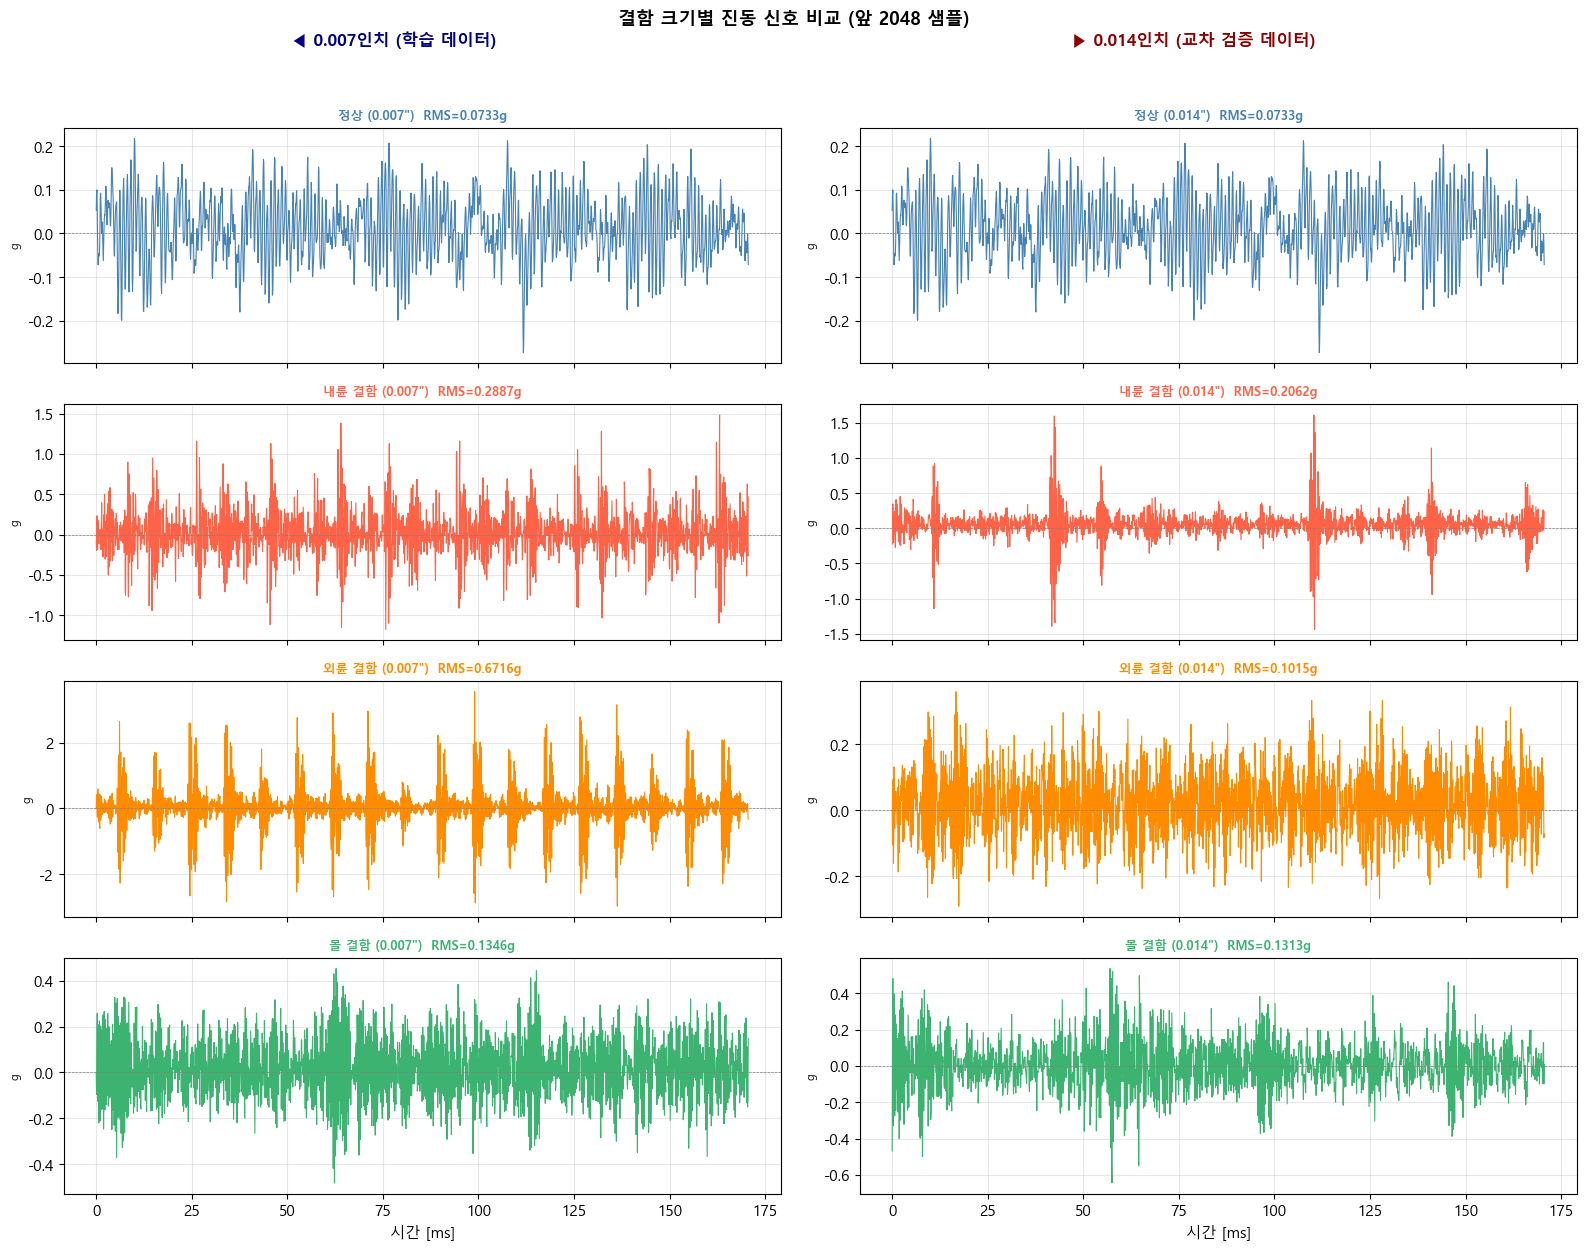

In [4]:
N = 2048
fig, axes = plt.subplots(4, 2, figsize=(16, 12), sharex=True)

for row, label in enumerate(['Normal', 'IR', 'OR', 'Ball']):
    for col, (sig_dict, size) in enumerate([(signals_007, '0.007"'), (signals_014, '0.014"')]):
        sig = sig_dict[label]
        t = np.arange(N) / fs * 1000
        axes[row, col].plot(t, sig[:N], color=COLORS[label], lw=0.8)
        axes[row, col].axhline(0, color='gray', lw=0.5, ls='--')
        axes[row, col].grid(True, alpha=0.3)
        rms = np.sqrt(np.mean(sig[:N]**2))
        axes[row, col].set_title(
            f'{LABEL_KR[label]} ({size})  RMS={rms:.4f}g',
            fontsize=9, color=COLORS[label], fontweight='bold')
        axes[row, col].set_ylabel('g', fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('시간 [ms]')

# 컬럼 헤더 — fig.text로 서브플롯 제목을 덮어쓰지 않음
fig.text(0.25, 1.01, '◀ 0.007인치 (학습 데이터)', ha='center',
         fontsize=12, fontweight='bold', color='navy')
fig.text(0.75, 1.01, '▶ 0.014인치 (교차 검증 데이터)', ha='center',
         fontsize=12, fontweight='bold', color='darkred')
fig.suptitle('결함 크기별 진동 신호 비교 (앞 2048 샘플)', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(pathlib.Path('data')/'01_파형비교.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. 특징 추출

진동 신호 1개 세그먼트(1024 샘플 = 약 85ms) → 숫자 7개 요약

| 특징 | 의미 | 결함 감지 역할 |
|------|------|---------------|
| RMS | 진동 에너지 평균 | 에너지가 클수록 결함 가능성 ↑ |
| Peak | 순간 최댓값 | 충격성 신호 포착 |
| Peak-to-Peak | 최대-최소 범위 | 진동 폭 |
| Crest Factor | Peak/RMS | 에너지 대비 충격 날카로움 |
| **Kurtosis** | 분포 뾰족함 (정상=3) | **충격 횟수/강도** → OR(7.6) > IR(5.4) >> Ball(3.0) ≈ Normal(2.8) |
| Skewness | 분포 비대칭성 | 비선형 충격 패턴 |
| Shape Factor | RMS/평균절댓값 | 파형 형태 |

**Kurtosis 순서의 물리적 근거**  
OR: 외륜 고정 → 볼이 6시 방향(하중대)의 결함을 항상 같은 힘으로 강타 → 일정하고 강한 충격 → 가장 높음  
IR: 내륜 회전 → 결함이 하중대를 통과할 때만 충격 → 변조된 충격  
Ball: 볼 자전 → 접촉점이 불규칙 → 충격 약하고 불규칙 ≈ Normal

In [5]:
def extract_features(x):
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))
    mean_abs = np.mean(np.abs(x))
    return {
        'RMS':          rms,
        'Peak':         peak,
        'Peak-to-Peak': np.ptp(x),
        'Crest_Factor': peak / (rms + 1e-10),
        'Kurtosis':     float(kurtosis(x, fisher=False)),
        'Skewness':     float(skew(x)),
        'Shape_Factor': rms / (mean_abs + 1e-10),
    }

FEATURE_COLS = ['RMS', 'Peak', 'Peak-to-Peak', 'Crest_Factor', 'Kurtosis', 'Skewness', 'Shape_Factor']
WINDOW = 1024
STEP   = 512

print('=== 결함 크기별 특징값 비교 (전체 신호) ===')
for label in ['Normal', 'IR', 'OR', 'Ball']:
    f1 = extract_features(signals_007[label])
    f2 = extract_features(signals_014[label])
    print(f'{label:8s} | RMS   0.007"={f1["RMS"]:.3f}g  0.014"={f2["RMS"]:.3f}g  '
          f'| Kurtosis  0.007"={f1["Kurtosis"]:.2f}  0.014"={f2["Kurtosis"]:.2f}')

=== 결함 크기별 특징값 비교 (전체 신호) ===
Normal   | RMS   0.007"=0.074g  0.014"=0.074g  | Kurtosis  0.007"=2.76  0.014"=2.76
IR       | RMS   0.007"=0.292g  0.014"=0.198g  | Kurtosis  0.007"=5.40  0.014"=21.96
OR       | RMS   0.007"=0.670g  0.014"=0.101g  | Kurtosis  0.007"=7.65  0.014"=3.06
Ball     | RMS   0.007"=0.139g  0.014"=0.153g  | Kurtosis  0.007"=2.98  0.014"=17.77


## 4. 학습 데이터셋 생성 (신호 단위 분할 — Data Leakage 방지)

**문제:** 겹침 50% 세그먼트 랜덤 분할 → 학습/테스트가 거의 같은 구간 → 100% 허위 발생  
**해결:** 신호 앞 70% → 학습, 뒤 30% → 테스트 (물리적으로 다른 구간)

```
[====== 학습 70% ======][=== 테스트 30% ===]
                       ↑ 겹침 없음
```

In [6]:
def make_df(signals_dict, start_r, end_r, max_seg=None):
    records = []
    for label, sig in signals_dict.items():
        n = len(sig)
        s, e = int(n * start_r), int(n * end_r)
        count = 0
        for idx in range(s, e - WINDOW, STEP):
            feat = extract_features(sig[idx:idx + WINDOW])
            feat['label'] = label
            records.append(feat)
            count += 1
            if max_seg and count >= max_seg:
                break
    return pd.DataFrame(records)

df_train      = make_df(signals_007, 0,   0.7, max_seg=140)
df_test_same  = make_df(signals_007, 0.7, 1.0, max_seg=60)
df_test_cross = make_df(signals_014, 0,   1.0, max_seg=60)

X_train      = df_train[FEATURE_COLS].values
y_train      = df_train['label'].values
X_test_same  = df_test_same[FEATURE_COLS].values
y_test_same  = df_test_same['label'].values
X_test_cross = df_test_cross[FEATURE_COLS].values
y_test_cross = df_test_cross['label'].values

print(f'학습셋    (0.007" 앞70%): {len(X_train):>4}개')
print(f'테스트셋1 (0.007" 뒤30%): {len(X_test_same):>4}개  ← 동일 조건')
print(f'테스트셋2 (0.014" 전체):  {len(X_test_cross):>4}개  ← 교차 검증')

학습셋    (0.007" 앞70%):  560개
테스트셋1 (0.007" 뒤30%):  240개  ← 동일 조건
테스트셋2 (0.014" 전체):   240개  ← 교차 검증


## 5. 특징별 분포 시각화 — 결함 종류를 구별할 수 있는가?

각 특징이 4가지 결함 클래스를 얼마나 잘 분리하는지 시각화.  
박스가 겹치지 않을수록 그 특징 하나로도 결함 구별 가능.

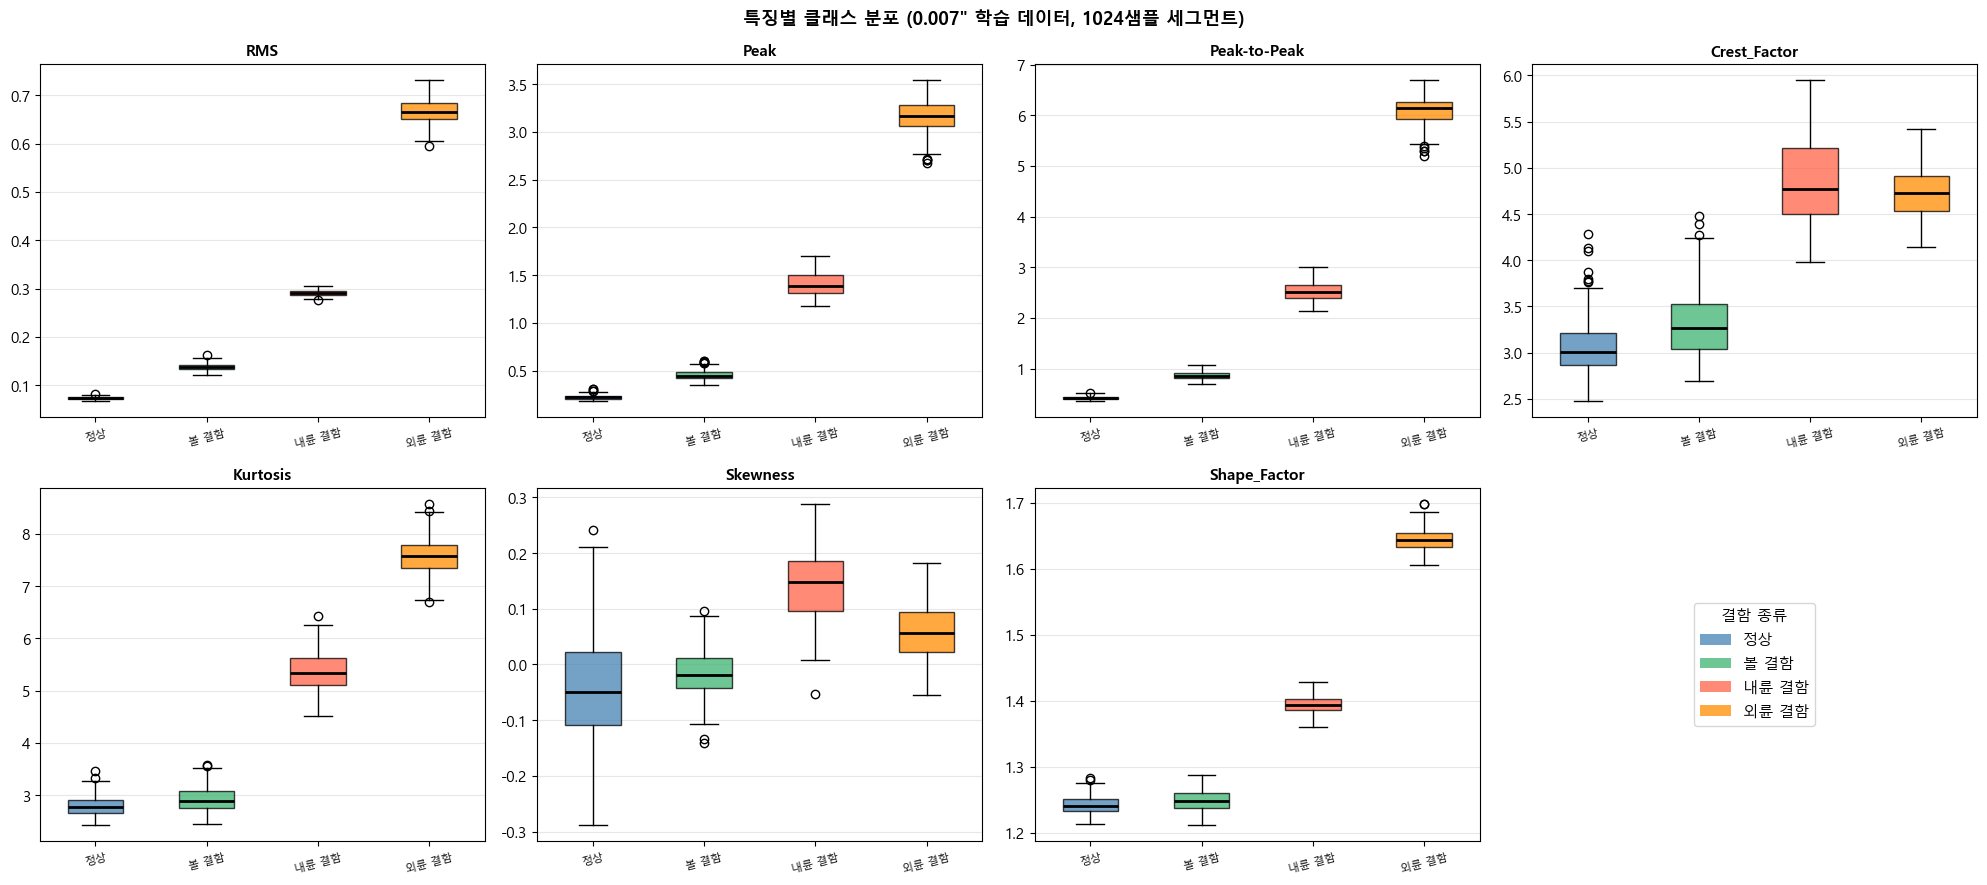


=== 클래스별 평균값 ===
          RMS   Peak  Peak-to-Peak  Crest_Factor  Kurtosis  Skewness  Shape_Factor
label                                                                             
Ball    0.138  0.458         0.871         3.321     2.931    -0.015         1.250
IR      0.291  1.405         2.512         4.827     5.369     0.144         1.394
Normal  0.073  0.224         0.422         3.064     2.798    -0.041         1.242
OR      0.668  3.161         6.109         4.736     7.561     0.056         1.645


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

box_colors = [COLORS[c] for c in CLASS_ORDER]

for idx, feat in enumerate(FEATURE_COLS):
    ax = axes[idx]
    data_per_class = [df_train[df_train['label'] == c][feat].values for c in CLASS_ORDER]
    bp = ax.boxplot(data_per_class, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(CLASS_ORDER) + 1))
    ax.set_xticklabels([LABEL_KR[c] for c in CLASS_ORDER], fontsize=8, rotation=15)
    ax.set_title(feat, fontweight='bold', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

# 마지막 빈 서브플롯에 범례 배치
ax_legend = axes[7]
ax_legend.axis('off')
for c in CLASS_ORDER:
    ax_legend.bar(0, 0, color=COLORS[c], label=LABEL_KR[c], alpha=0.75)
ax_legend.legend(loc='center', fontsize=11, title='결함 종류', title_fontsize=11)

fig.suptitle('특징별 클래스 분포 (0.007" 학습 데이터, 1024샘플 세그먼트)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(pathlib.Path('data') / '02_특징분포.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== 클래스별 평균값 ===')
print(df_train.groupby('label')[FEATURE_COLS].mean().round(3).to_string())

## 6. RandomForest 학습 & 두 가지 테스트

In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_same  = model.predict(X_test_same)
y_pred_cross = model.predict(X_test_cross)

acc_same  = accuracy_score(y_test_same,  y_pred_same)
f1_same   = f1_score(y_test_same,  y_pred_same,  average='macro')
acc_cross = accuracy_score(y_test_cross, y_pred_cross)
f1_cross  = f1_score(y_test_cross, y_pred_cross, average='macro')

print('=' * 60)
print(f'  테스트1 (0.007" → 0.007"): 정확도={acc_same:.4f}  F1={f1_same:.4f}')
print(f'  테스트2 (0.007" → 0.014"): 정확도={acc_cross:.4f}  F1={f1_cross:.4f}  ← 핵심')
print('=' * 60)
print()
print('--- 교차 검증 클래스별 상세 ---')
print(classification_report(y_test_cross, y_pred_cross,
                             target_names=sorted(set(y_test_cross))))

  테스트1 (0.007" → 0.007"): 정확도=1.0000  F1=1.0000
  테스트2 (0.007" → 0.014"): 정확도=0.6250  F1=0.5295  ← 핵심

--- 교차 검증 클래스별 상세 ---
              precision    recall  f1-score   support

        Ball       0.43      0.50      0.46        60
          IR       0.67      1.00      0.81        60
      Normal       0.74      1.00      0.85        60
          OR       0.00      0.00      0.00        60

    accuracy                           0.62       240
   macro avg       0.46      0.62      0.53       240
weighted avg       0.46      0.62      0.53       240



## 7. 혼동행렬 비교

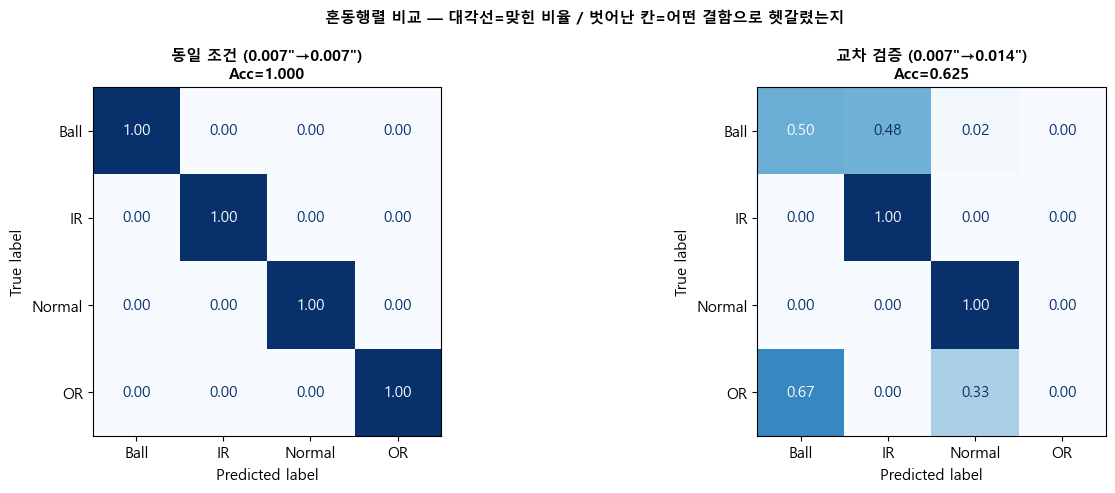

동일 조건: 100.0%  →  교차 검증: 62.5%
OR 0% 원인: 0.014" OR의 특징값 범위가 0.007" 학습 데이터 범위를 벗어남


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_names = sorted(set(y_test_same))

configs = [
    (y_test_same,  y_pred_same,  f'동일 조건 (0.007"→0.007")\nAcc={acc_same:.3f}'),
    (y_test_cross, y_pred_cross, f'교차 검증 (0.007"→0.014")\nAcc={acc_cross:.3f}'),
]

for ax, (y_t, y_p, title) in zip(axes, configs):
    cm = confusion_matrix(y_t, y_p, labels=class_names)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0.0)
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(title, fontweight='bold', fontsize=11)

fig.suptitle('혼동행렬 비교 — 대각선=맞힌 비율 / 벗어난 칸=어떤 결함으로 헷갈렸는지',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(pathlib.Path('data') / '03_혼동행렬.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'동일 조건: {acc_same*100:.1f}%  →  교차 검증: {acc_cross*100:.1f}%')
print('OR 0% 원인: 0.014" OR의 특징값 범위가 0.007" 학습 데이터 범위를 벗어남')

## 8. 특징 중요도

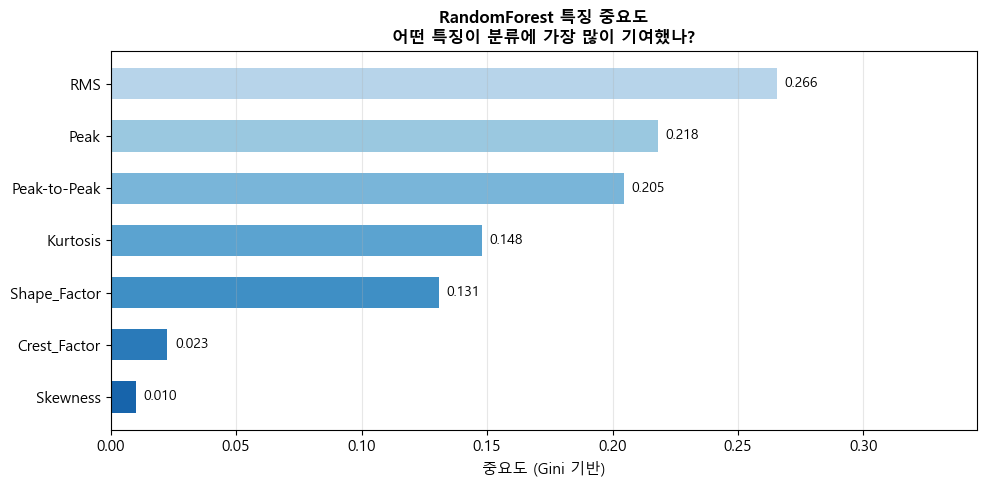

=== 특징 중요도 순위 ===
  1위 RMS            : 0.2656  █████████████████████████████████████████████████████
  2위 Peak           : 0.2183  ███████████████████████████████████████████
  3위 Peak-to-Peak   : 0.2046  ████████████████████████████████████████
  4위 Kurtosis       : 0.1481  █████████████████████████████
  5위 Shape_Factor   : 0.1307  ██████████████████████████
  6위 Crest_Factor   : 0.0226  ████
  7위 Skewness       : 0.0101  ██


In [10]:
feat_df = pd.DataFrame({
    '특징': FEATURE_COLS,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = plt.cm.Blues_r(np.linspace(0.2, 0.7, len(feat_df)))
y_pos = range(len(feat_df))
bars = ax.barh(y_pos, feat_df['중요도'][::-1].values,
               color=bar_colors, edgecolor='none', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_df['특징'][::-1].values, fontsize=11)
ax.set_xlabel('중요도 (Gini 기반)', fontsize=11)
ax.set_title('RandomForest 특징 중요도\n어떤 특징이 분류에 가장 많이 기여했나?',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, feat_df['중요도'].max() * 1.3)
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, feat_df['중요도'][::-1].values):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()  # 레이블 자동 여백 조정
plt.savefig(pathlib.Path('data') / '04_특징중요도.png', dpi=120, bbox_inches='tight')
plt.show()

print('=== 특징 중요도 순위 ===')
for rank, (_, row) in enumerate(feat_df.iterrows(), 1):
    bar_len = int(row['중요도'] * 200)
    print(f'  {rank}위 {row["특징"]:15s}: {row["중요도"]:.4f}  {"█" * bar_len}')

## 9. 결론 & 한계

| 평가 방식 | 정확도 | 의미 |
|----------|--------|------|
| 동일 조건 (0.007"→0.007") | ~100% | 같은 크기 결함 완벽 인식 |
| 교차 검증 (0.007"→0.014") | ~62% | 결함 크기 변화에 취약 |

### OR(외륜) 0% — 핵심 발견

모델은 0.007" OR의 특징 범위(RMS ~0.67g)를 "외륜 결함"으로 학습했다.  
0.014" OR은 RMS가 2배 이상 높아져 모델이 학습한 범위를 벗어남 → 전혀 다른 클래스로 분류.  
이는 버그가 아니라 **단일 결함 크기 학습의 구조적 한계**를 드러내는 결과.

### 다음 단계
1. 다양한 결함 크기 혼합 학습 (0.007" + 0.014" + 0.021")
2. 특징 정규화 — 절대값 대신 기준값 대비 상대값 사용
3. FFT 주파수 특징 추가 — 결함 크기와 무관한 주파수 패턴 활용

### 면접 답변
> CWRU 베어링 데이터로 시간영역 특징 7종을 추출하고 RandomForest로 4가지 결함을 분류했습니다.  
> 동일 조건에서 100%였지만 교차 검증(0.007"→0.014") 결과 62.5%로 하락했으며,  
> 외륜 결함 인식률이 0%로 나타났습니다. 모델이 결함 크기 자체를 과적합한 결과이며,  
> 현장 배포를 위해 다양한 결함 크기 데이터 학습 또는 특징 정규화가 필요함을 확인했습니다.